In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras import layers, models

In [2]:
print("TensorFlow:", tf.__version__)

# GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✅ GPU detected")
else:
    print("⚠️ Running on CPU")

TensorFlow: 2.10.0
✅ GPU detected


In [3]:
DATA_PATH = "data"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10



In [4]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_gen.flow_from_directory(
    f"{DATA_PATH}/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_data = val_gen.flow_from_directory(
    f"{DATA_PATH}/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 8249 images belonging to 2 classes.
Found 1768 images belonging to 2 classes.


In [5]:
def build_model():
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

model = build_model()
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                                             

In [6]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor="val_loss",        # monitor validation loss
    patience=3,                # wait 3 epochs before stopping
    restore_best_weights=True, # VERY IMPORTANT
    verbose=1
)

In [7]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

Epoch 1/10
258/258 [==============================] - 207s 771ms/step - loss: 0.0248 - accuracy: 0.9901 - val_loss: 0.0012 - val_accuracy: 1.0000
Epoch 2/10
258/258 [==============================] - 66s 256ms/step - loss: 0.0062 - accuracy: 0.9976 - val_loss: 9.6939e-04 - val_accuracy: 0.9994
Epoch 3/10
258/258 [==============================] - 68s 265ms/step - loss: 0.0045 - accuracy: 0.9985 - val_loss: 0.0014 - val_accuracy: 0.9994
Epoch 4/10
258/258 [==============================] - 67s 258ms/step - loss: 0.0042 - accuracy: 0.9981 - val_loss: 4.9435e-04 - val_accuracy: 1.0000
Epoch 5/10
258/258 [==============================] - 66s 257ms/step - loss: 0.0049 - accuracy: 0.9982 - val_loss: 0.0040 - val_accuracy: 0.9989
Epoch 6/10
258/258 [==============================] - 66s 256ms/step - loss: 0.0011 - accuracy: 0.9995 - val_loss: 7.3774e-04 - val_accuracy: 0.9994
Epoch 7/10
258/258 [==============================] - 66s 256ms/step - loss: 0.0038 - accuracy: 0.9993 - val_loss: 8.

In [8]:
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_data = test_gen.flow_from_directory(
    f"{DATA_PATH}/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False   # VERY IMPORTANT
)

Found 1768 images belonging to 2 classes.


In [9]:
test_data.reset()

preds = model.predict(test_data)
y_pred = (preds > 0.5).astype(int).flatten()
y_true = test_data.classes

56/56 [==============================] - 22s 379ms/step


In [10]:
print(classification_report(y_true, y_pred, target_names=["non_tomato", "tomato"]))

              precision    recall  f1-score   support

  non_tomato       1.00      1.00      1.00       868
      tomato       1.00      1.00      1.00       900

    accuracy                           1.00      1768
   macro avg       1.00      1.00      1.00      1768
weighted avg       1.00      1.00      1.00      1768



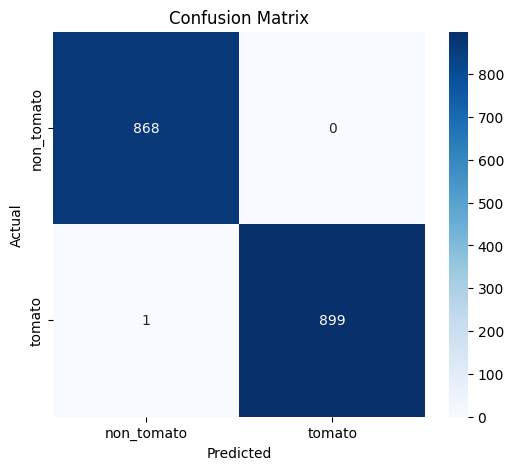

In [11]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["non_tomato", "tomato"],
            yticklabels=["non_tomato", "tomato"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [12]:
cm

array([[868,   0],
       [  1, 899]], dtype=int64)

In [13]:
thresholds = [0.5, 0.6, 0.7, 0.8]

for t in thresholds:
    y_pred_t = (preds > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_true, y_pred_t))


Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       868
           1       1.00      1.00      1.00       900

    accuracy                           1.00      1768
   macro avg       1.00      1.00      1.00      1768
weighted avg       1.00      1.00      1.00      1768


Threshold: 0.6
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       868
           1       1.00      1.00      1.00       900

    accuracy                           1.00      1768
   macro avg       1.00      1.00      1.00      1768
weighted avg       1.00      1.00      1.00      1768


Threshold: 0.7
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       868
           1       1.00      1.00      1.00       900

    accuracy                           1.00      1768
   macro avg       1.00      1.00      1.00      1768
weighted avg       1.00   

In [14]:
model.save("tomato_leaf_validator.h5")

print("✅ Model saved")

✅ Model saved
